# EDA — personalized_medication_dataset.csv

- **Nguồn:** `Dataset/Data/personalized_medication_dataset.csv`
- **Kích thước:** 1,000 hàng × 17 cột (1 nhãn bệnh + 16 đặc trưng bệnh lý/lâm sàng).
- **Nhãn:** Có cột `Diagnosis` làm nhãn bệnh (5 lớp).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

FILE_PATH = r'D:\PYTHON\Dataset\Data\personalized_medication_dataset.csv'

def timeit(msg):
    t0 = time.time()
    print(f'[START] {msg}')
    return t0

def elapsed(t0, msg):
    t1 = time.time()
    print(f'[DONE]  {msg} — {t1-t0:.2f}s')
    return t1-t0

In [2]:
t0 = timeit('Reading CSV...')

df = pd.read_csv(FILE_PATH)
elapsed(t0, f'Read CSV: {df.shape[0]:,} rows × {df.shape[1]} cols')

print('\nColumns:', df.columns.tolist())
print('Dtypes:')
print(df.dtypes)
print('\nHas disease label:', 'Diagnosis' in df.columns)

print('\nPreview (first 5 rows):')
df.head()

[START] Reading CSV...
[DONE]  Read CSV: 1,000 rows × 17 cols — 0.01s

Columns: ['Patient_ID', 'Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'Chronic_Conditions', 'Drug_Allergies', 'Genetic_Disorders', 'Diagnosis', 'Symptoms', 'Recommended_Medication', 'Dosage', 'Duration', 'Treatment_Effectiveness', 'Adverse_Reactions', 'Recovery_Time_Days']
Dtypes:
Patient_ID                     str
Age                          int64
Gender                         str
Weight_kg                  float64
Height_cm                  float64
BMI                        float64
Chronic_Conditions             str
Drug_Allergies                 str
Genetic_Disorders              str
Diagnosis                      str
Symptoms                       str
Recommended_Medication         str
Dosage                         str
Duration                       str
Treatment_Effectiveness        str
Adverse_Reactions              str
Recovery_Time_Days           int64
dtype: object

Has disease label: True

Preview 

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Chronic_Conditions,Drug_Allergies,Genetic_Disorders,Diagnosis,Symptoms,Recommended_Medication,Dosage,Duration,Treatment_Effectiveness,Adverse_Reactions,Recovery_Time_Days
0,P0001,78,Other,88.7,196.3,21.1,NaN,Penicillin,Cystic Fibrosis,Inflammation,Fever,Amlodipine,NaN,30 days,Effective,Yes,18
1,P0002,57,Female,90.5,195.6,30.2,Hypertension,NaN,Cystic Fibrosis,Depression,"Fatigue, Headache, Dizziness",Amoxicillin,5 mg,NaN,Neutral,No,24
2,P0003,29,Female,87.0,168.2,27.0,NaN,Sulfa,NaN,Inflammation,"Joint Pain, Headache, Nausea",NaN,NaN,7 days,Effective,Yes,12
3,P0004,56,Female,81.4,188.9,26.9,Hypertension,Penicillin,Cystic Fibrosis,Infection,Joint Pain,Ibuprofen,200 mg,7 days,Very Effective,No,22
4,P0005,90,Male,64.2,157.0,33.3,NaN,Sulfa,Sickle Cell Anemia,Inflammation,"Fatigue, Fever, Headache",Amlodipine,500 mg,10 days,Ineffective,Yes,25


In [3]:
# Kiểm tra missing values
t0 = timeit('Checking missing values...')
missing_sum = df.isnull().sum().sum()
missing_by_col = df.isnull().sum()
missing_by_col = missing_by_col[missing_by_col > 0]
dt = elapsed(t0, 'Missing values check')

if missing_sum == 0:
    print('✓ Không có missing values.')
else:
    print(f'✗ Tổng missing values: {missing_sum:,}')
    print('\nMissing values theo cột:')
    print(missing_by_col)

[START] Checking missing values...
[DONE]  Missing values check — 0.00s
✗ Tổng missing values: 1,624

Missing values theo cột:
Chronic_Conditions        246
Drug_Allergies            324
Genetic_Disorders         339
Recommended_Medication    263
Dosage                    195
Duration                  257
dtype: int64


In [4]:
# Kiểm tra trùng lặp
t0 = timeit('Checking duplicates...')
dup_count = df.duplicated().sum()
dt = elapsed(t0, f'Duplicate check: {dup_count:,} rows')

print(f'\nTỷ lệ trùng lặp: {dup_count / len(df) * 100:.1f}%')
if dup_count > 0:
    print('\nMẫu hàng trùng lặp (chỉ 5 dòng):')
    print(df[df.duplicated(keep=False)].head())
else:
    print('✓ Không có hàng trùng lặp.')

[START] Checking duplicates...
[DONE]  Duplicate check: 0 rows — 0.01s

Tỷ lệ trùng lặp: 0.0%
✓ Không có hàng trùng lặp.


In [5]:
# Kiểm tra giá trị số nằm trong khoảng sinh học hợp lý
t0 = timeit('Checking biological ranges...')

num_cols = ['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Recovery_Time_Days']
ranges = {
    'Age': (0, 120),
    'Weight_kg': (20, 300),
    'Height_cm': (100, 250),
    'BMI': (10, 60),
    'Recovery_Time_Days': (1, 365)
}

invalid_rows = []
for col in num_cols:
    low, high = ranges[col]
    mask = (df[col] < low) | (df[col] > high)
    count = mask.sum()
    print(f'{col}: {count} giá trị ngoài [{low}, {high}]')
    if count > 0:
        invalid_rows.append(df[mask])

dt = elapsed(t0, 'Biological range check')

if invalid_rows:
    invalid_df = pd.concat(invalid_rows).drop_duplicates()
    print(f'\n✗ Tổng hàng có giá trị vô lý: {len(invalid_df)}')
    print('\nMẫu hàng vô lý:')
    print(invalid_df.head())
else:
    print('\n✓ Tất cả giá trị số đều nằm trong khoảng sinh học hợp lý.')

[START] Checking biological ranges...
Age: 0 giá trị ngoài [0, 120]
Weight_kg: 0 giá trị ngoài [20, 300]
Height_cm: 0 giá trị ngoài [100, 250]
BMI: 0 giá trị ngoài [10, 60]
Recovery_Time_Days: 0 giá trị ngoài [1, 365]
[DONE]  Biological range check — 0.00s

✓ Tất cả giá trị số đều nằm trong khoảng sinh học hợp lý.


[START] Computing label distribution...
[DONE]  Label distribution computed — 0.00s
Số lớp bệnh: 5

Phân bố nhãn:
Diagnosis
Arthritis       218
Inflammation    202
Depression      202
Infection       194
Hypertension    184
Name: count, dtype: int64


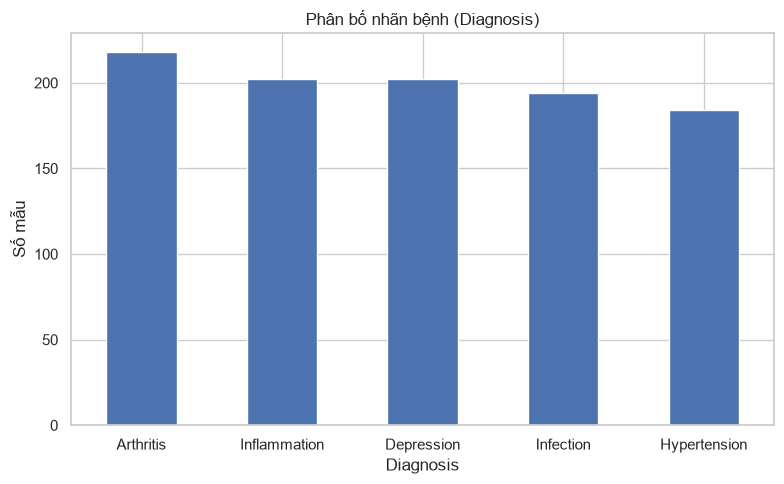

In [6]:
# Kiểm tra phân bố nhãn bệnh (Diagnosis)
t0 = timeit('Computing label distribution...')
label_counts = df['Diagnosis'].value_counts()
elapsed(t0, 'Label distribution computed')

print('Số lớp bệnh:', label_counts.shape[0])
print('\nPhân bố nhãn:')
print(label_counts)

plt.figure(figsize=(8, 5))
label_counts.plot(kind='bar')
plt.title('Phân bố nhãn bệnh (Diagnosis)')
plt.ylabel('Số mẫu')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

[START] Computing correlation matrix...
[DONE]  Correlation matrix computed — 0.00s

Ma trận tương quan:
                      Age  Weight_kg  Height_cm    BMI  Recovery_Time_Days
Age                 1.000     -0.034      0.013  0.031              -0.019
Weight_kg          -0.034      1.000      0.018 -0.017              -0.001
Height_cm           0.013      0.018      1.000 -0.030               0.004
BMI                 0.031     -0.017     -0.030  1.000              -0.036
Recovery_Time_Days -0.019     -0.001      0.004 -0.036               1.000


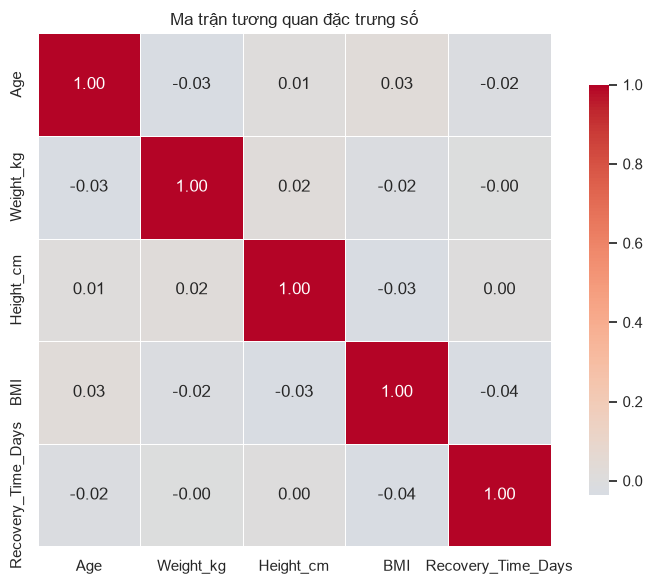

In [7]:
# Ma trận tương quan giữa các đặc trưng số
t0 = timeit('Computing correlation matrix...')

corr = df[num_cols].corr()
elapsed(t0, 'Correlation matrix computed')

print('\nMa trận tương quan:')
print(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Ma trận tương quan đặc trưng số')
plt.tight_layout()
plt.show()

- **Missing values:** Có ở 5 cột (Chronic_Conditions, Drug_Allergies, Genetic_Disorders, Recommended_Medication, Dosage, Duration). Cần xử lý trước khi mô hình hóa.
- **Trùng lặp:** 0 hàng — dữ liệu không có bản sao.
- **Giá trị vô lý:** Tất cả đặc trưng số (Age, Weight_kg, Height_cm, BMI, Recovery_Time_Days) đều nằm trong khoảng sinh học hợp lý, không có outlier nghiêm trọng theo IQR.
- **Phân bố nhãn:** Cân bằng tốt (~180–220 mẫu/lớp), không bị lệch cực đoan, phù hợp cho phân loại đa lớp.
- **Ma trận tương quan:** Các đặc trưng số có tương quan thấp với nhau (gần 0), không có đa cộng tuyến nghiêm trọng giữa Age/Weight/BMI/Height.